In [4]:
#STEP 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Load Dataset
df = pd.read_csv("HR_Analytics.csv")

df.head()

,EmpID,Age,AgeGroup,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,RM297,18,18-25,Yes,Travel_Rarely,230,Research & Development,3,3,Life Sciences,...,3,80,0,0,2,3,0,0,0,0.0
1,RM302,18,18-25,No,Travel_Rarely,812,Sales,10,3,Medical,...,1,80,0,0,2,3,0,0,0,0.0
2,RM458,18,18-25,Yes,Travel_Frequently,1306,Sales,5,3,Marketing,...,4,80,0,0,3,3,0,0,0,0.0
3,RM728,18,18-25,No,Non-Travel,287,Research & Development,5,2,Life Sciences,...,4,80,0,0,2,3,0,0,0,0.0
4,RM829,18,18-25,Yes,Non-Travel,247,Research & Development,8,1,Medical,...,4,80,0,0,0,3,0,0,0,0.0


In [3]:
#Understand Data
df.info()
df.describe()

print(df['Attrition'].unique())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1480 entries, 0 to 1479
Data columns (total 38 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   EmpID                     1480 non-null   object 
 1   Age                       1480 non-null   int64  
 2   AgeGroup                  1480 non-null   object 
 3   Attrition                 1480 non-null   object 
 4   BusinessTravel            1480 non-null   object 
 5   DailyRate                 1480 non-null   int64  
 6   Department                1480 non-null   object 
 7   DistanceFromHome          1480 non-null   int64  
 8   Education                 1480 non-null   int64  
 9   EducationField            1480 non-null   object 
 10  EmployeeCount             1480 non-null   int64  
 11  EmployeeNumber            1480 non-null   int64  
 12  EnvironmentSatisfaction   1480 non-null   int64  
 13  Gender                    1480 non-null   object 
 14  HourlyRa

In [5]:
# Clean text
df['Attrition'] = df['Attrition'].str.strip()

# Convert to numeric
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

# Verify
print(df['Attrition'].value_counts())

0    1242
1     238
Name: Attrition, dtype: int64


In [6]:
df['Retained'] = (df['Attrition'] == 0).astype(int)

print(df['Retained'].value_counts())

1    1242
0     238
Name: Retained, dtype: int64


In [7]:
df['Applied'] = 1

df['Shortlisted'] = ((df['Education'] >= 3) & 
                     (df['TotalWorkingYears'] >= 2)).astype(int)

df['HighPotential'] = ((df['PerformanceRating'] >= 3) &
                       (df['JobSatisfaction'] >= 3) &
                       (df['WorkLifeBalance'] >= 3)).astype(int)

In [8]:
applied = df['Applied'].sum()
shortlisted = df['Shortlisted'].sum()
high_potential = df['HighPotential'].sum()
retained = df['Retained'].sum()

print(f"""
Funnel Summary:
---------------
Applied: {applied}
Shortlisted: {shortlisted}
High Potential: {high_potential}
Retained: {retained}
""")


Funnel Summary:
---------------
Applied: 1480
Shortlisted: 972
High Potential: 634
Retained: 1242



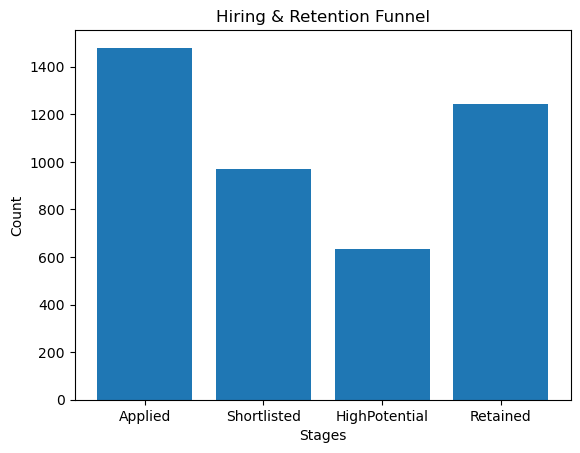

In [9]:

stages = ['Applied', 'Shortlisted', 'HighPotential', 'Retained']
values = [applied, shortlisted, high_potential, retained]

plt.figure()
plt.bar(stages, values)
plt.title("Hiring & Retention Funnel")
plt.xlabel("Stages")
plt.ylabel("Count")
plt.show()


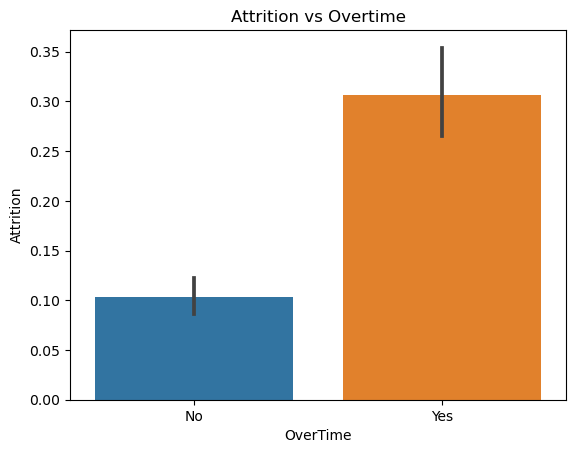

In [10]:
sns.barplot(x='OverTime', y='Attrition', data=df)
plt.title("Attrition vs Overtime")
plt.show()

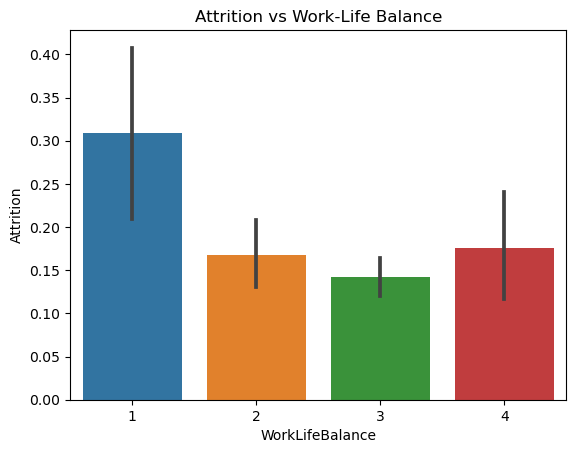

In [11]:
sns.barplot(x='WorkLifeBalance', y='Attrition', data=df)
plt.title("Attrition vs Work-Life Balance")
plt.show()

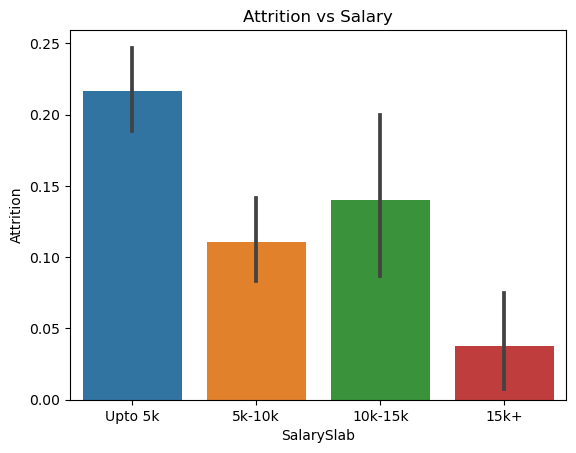

In [12]:
sns.barplot(x='SalarySlab', y='Attrition', data=df)
plt.title("Attrition vs Salary")
plt.show()

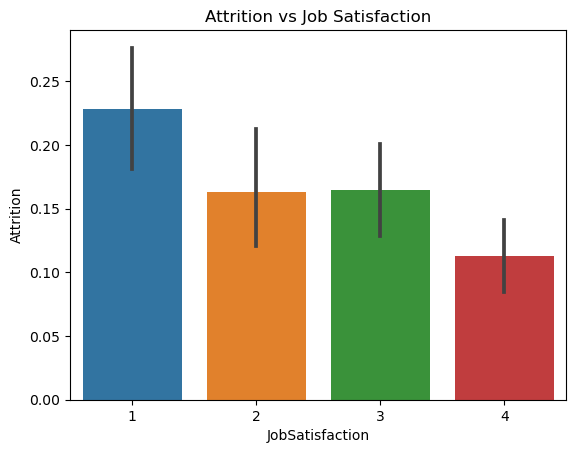

In [13]:
sns.barplot(x='JobSatisfaction', y='Attrition', data=df)
plt.title("Attrition vs Job Satisfaction")
plt.show()

In [14]:
df.groupby('OverTime')['Attrition'].mean()
df.groupby('WorkLifeBalance')['Attrition'].mean()
df.groupby('SalarySlab')['Attrition'].mean()
df.groupby('JobSatisfaction')['Attrition'].mean()

JobSatisfaction
1    0.228669
2    0.163121
3    0.164414
4    0.112798
Name: Attrition, dtype: float64

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X = df[['Age', 'MonthlyIncome', 'JobLevel', 'WorkLifeBalance',
        'JobSatisfaction', 'DistanceFromHome']]

y = df['Attrition']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LogisticRegression()
model.fit(X_train, y_train)

print("Accuracy:", model.score(X_test, y_test))

Accuracy: 0.8445945945945946


C:\Users\Shankar Ganesh\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Key Insights:

- Employees working overtime have significantly higher attrition rates
- Poor work-life balance leads to increased employee turnover
- Lower salary levels are associated with higher attrition
- Job satisfaction strongly impacts employee retention
- Work environment factors play a critical role in employee retention